# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

**Business Problem:**

*[ The main business problem I want to address is understanding customer satisfaction throuhgh written Amazon headphone reviews. Manually reading thousands of reviews would take up a significant amount of time. A sentiment analysis model could help  automatically classify these reviews and make it easier for a business to identify the overall sentiment of their customer. ]*


---

**Dataset Description:**

*[For this project, I'm using a public dataset obtained from Kagggle, containing Amazon customer reviews for headphones. The dataset includes the customer's written comments along with a rating from 1 to 5 stars. The written comments will be used as the text input for the machine learning models while the ratings will be converted into sentiment labels.]*

- **Dataset name**: Headphone Dataset Review Analysis
- **Source**: Kaggle-- Amazon headphone customer reviews
- **Number of samples**: 1,604 customer reviews
- **Text type**: Customer submitted written reviews on Amazon
- **Sentiment labels**:
  * **Negative** = 1-2 stars
  * **Neutral** = 3 stars
  * **Positive** = 4-5 stars

---

**Importance and Real-World Applications:**

*[Customer reviews provide businesses with valuable insight of how people actually feel about their products. Sentiment analysis allows companies to process those large numbers of reviews more quickly than reading through each one individually.

For a headphone company or an Amazon seller, this could help identify common complaints   such as sound quality, fit/comfort, battery life, bluetooth connectivity, or product durability. This type of information allows  businesses to improve their products, address customer concerns, and make better decisions based on real feedback. ]*

---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [52]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [53]:
#import pandas as pd

# Load your dataset
df = pd.read_csv("headphone_datn.csv")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

df.head()

Dataset shape: (1604, 6)

Column names: ['Customer_Name', 'REVIEW_TITLE', 'Color', 'REVIEW_DATE', 'COMMENTS', 'RATINGS']


,Customer_Name,REVIEW_TITLE,Color,REVIEW_DATE,COMMENTS,RATINGS
0,Ramdika,Really Exceed my expectation.,Black,30-May-21,Okay.. I was skeptical at first to buy this as...,5
1,Sachin AK,Great for a change from inear buds,Black,01-Jun-21,The earphone is worth what you pay for. The de...,5
2,Manikandan Raj,For people with sensitive ears,Black,05-Sep-21,"Particularly for people with sensitive ears, w...",4
3,Reviewguy,I tested it for a week and here's a detailed r...,Iguana,11-Sep-21,Built Quality 6.5 10The lower wire is a durabl...,4
4,Sridhar Sarkar,Not a good headphone,Iguana,26-Jun-21,Don't go with the over all 4 start rating. Thi...,2


In [54]:
# Check for missing values
df.isnull().sum()

,0
Customer_Name,0
REVIEW_TITLE,10
Color,0
REVIEW_DATE,0
COMMENTS,58
RATINGS,0


In [55]:
# 🎯 IMPORTANT: If working with limited resources, sample your data here
# Uncomment and modify as needed:

# df_sample = df.sample(n=5000, random_state=42)
# print(f"Working with {len(df_sample)} samples")
# df = df_sample  # Use the sample for the rest of the project

Sentiment
Positive    933
Negative    520
Neutral     151
Name: count, dtype: int64


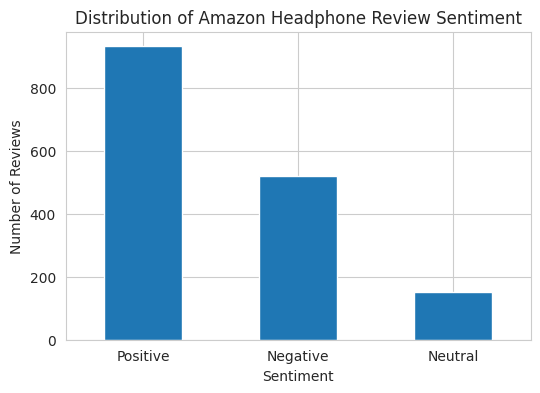

In [56]:
import matplotlib.pyplot as plt

# Convert ratings into sentiment labels
def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

# Create the new Sentiment column
df["Sentiment"] = df["RATINGS"].apply(get_sentiment)

# Count each sentiment
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

# Create a bar chart
plt.figure(figsize=(6,4))
sentiment_counts.plot(kind="bar")

plt.title("Distribution of Amazon Headphone Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

### 📊 Interpretation: Class Balance

*Write your observations here:*
- Are the classes balanced or imbalanced?
- If imbalanced, how might this affect your model?
- What could you do to address imbalance?

The dataset is not balanced perfectly. Most reviews are positive and the neutral reviews are less common. This is expected due to customers tendencies to leave higher reviews when satisfied with a product. Even with a slight imbalance, each category still has enough reviews to train and evaluate machine learning models.

count    1546.000000
mean       83.769082
std       103.886310
min         2.000000
25%        18.000000
50%        50.000000
75%       112.000000
max      1433.000000
Name: text_length, dtype: float64


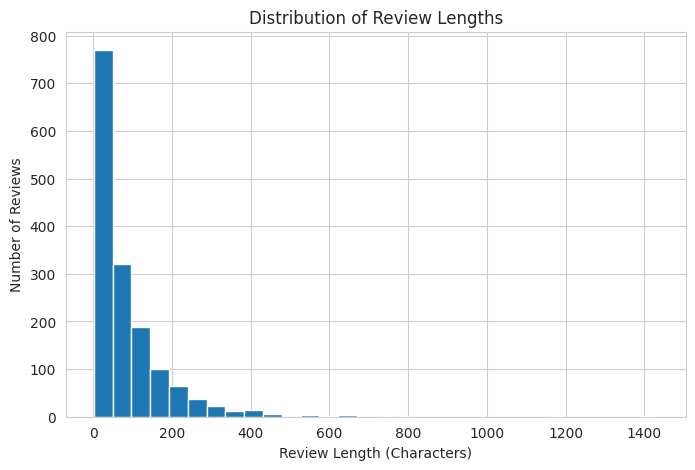


Average Review Length by Sentiment:
Sentiment
Negative    98.622047
Neutral     92.290541
Positive    73.874157
Name: text_length, dtype: float64


In [57]:
import matplotlib.pyplot as plt

# Create a new column for review length (number of characters)
df["text_length"] = df["COMMENTS"].str.len()

# Display summary statistics
print(df["text_length"].describe())

# Plot histogram of review lengths
plt.figure(figsize=(8,5))
plt.hist(df["text_length"], bins=30)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")

plt.show()

# Compare average review length by sentiment
print("\nAverage Review Length by Sentiment:")
print(df.groupby("Sentiment")["text_length"].mean())

### 📊 Interpretation: Text Length

*Write your observations here:*
- What's the average text length?
- Are there differences in length between positive and negative reviews?
- Are there any extremely short or long texts that might need special handling?

The review length analysis indicates that customers reviews vary considerably in sizes. Comparing length of review by sentiment shows that customers with negative reviews often provide detailed explanations of their experience. On the other hand, positive reviews are often succinct. The variation in review length provides useful context for building and evaluating the sentiment analysis models.

In [58]:
# Display sample reviews from each sentiment class

for sentiment in ["Positive", "Neutral", "Negative"]:
    print(f"\n{'='*60}")
    print(f"{sentiment} Reviews")
    print(f"{'='*60}")

    samples = df[df["Sentiment"] == sentiment].sample(
        min(3, len(df[df["Sentiment"] == sentiment])),
        random_state=42
    )

    print(samples[["RATINGS", "REVIEW_TITLE", "COMMENTS"]])


Positive Reviews
      RATINGS                      REVIEW_TITLE  \
1499        5                           Perfect   
150         5  Very basic but gets the job done   
1229        5                          Good one   

                                               COMMENTS  
1499     Received in well condition and working fine...  
150   Good built quality. Comfortable to wear. Wire ...  
1229                                      Good product.  

Neutral Reviews
     RATINGS                           REVIEW_TITLE  \
628        3                    Not worth for Rs ..   
195        3             okay sound, bad microphone   
712        3  Right earphone does not work properly   

                                              COMMENTS  
628  Not like boat 100.. Low quality sound.. no bas...  
195  if you're buying this for meetings calling, th...  
712  The media could not be loaded. Right earphone ...  

Negative Reviews
     RATINGS                                  REVIEW_TITLE  \

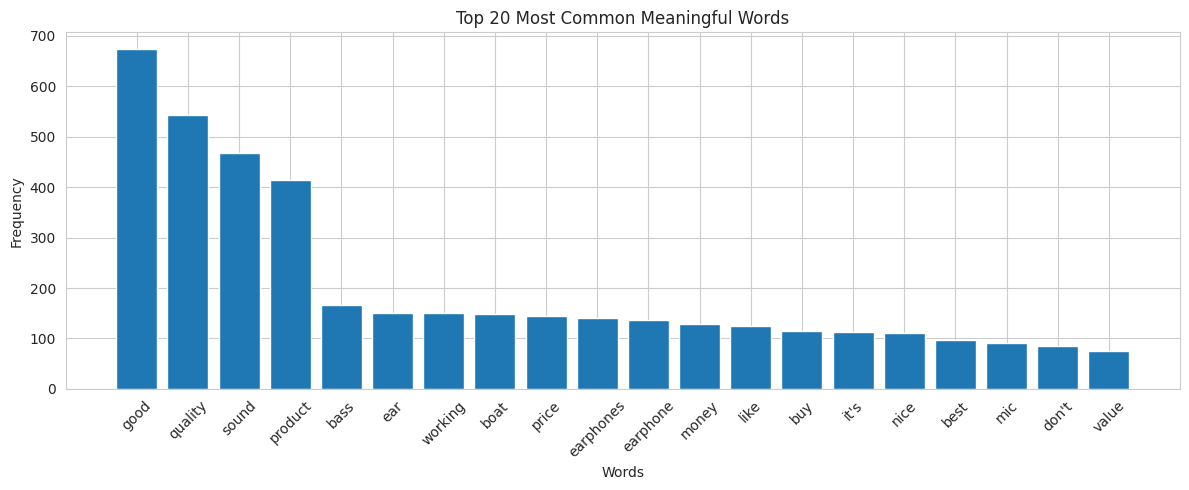

In [59]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt

all_words = " ".join(df["COMMENTS"].astype(str)).lower().split()

# Remove common stop words
filtered_words = [
    word.strip(".,!?()[]\"':;")
    for word in all_words
    if word not in ENGLISH_STOP_WORDS and len(word) > 2
]

common_words = Counter(filtered_words).most_common(20)

words = [w for w, c in common_words]
counts = [c for w, c in common_words]

plt.figure(figsize=(12,5))
plt.bar(words, counts)
plt.title("Top 20 Most Common Meaningful Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📝 EDA Summary

*Summarize your key findings from the EDA:*

1. **Dataset characteristics**:

The dataset initially included 1,604 Amazon headphone reviews across six columns: Customer_Name, REVIEW_TITLE, Color, REVIEW_DATE, COMMENTS, and RATINGS. After removing reviews with missing comments, 1,546 remained for analysis. A new Sentiment column was created by converting ratings into three categories: Negative (1–2 stars), Neutral (3 stars), and Positive (4–5 stars).

2. **Data quality issues**:

The primary data quality issue was 58 missing review comments, which were removed prior to analysis. Aside from the missing comments, the dataset was clean and suitable for sentiment analysis. Review lengths ranged from very short comments to detailed customer feedback.

3. **Key patterns observed**:

Positive reviews made up the largest share of the sentiment distribution, while neutral reviews were the least common. Review length varied considerably, with most reviews being relatively short, with a smaller subset offering more detailed descriptions. The most common words centered on product quality, sound, comfort, and overall customer experience.

4. **Potential challenges**:

The dataset shows slight imbalance because positive reviews substantially outnumber neutral and negative reviews. Common words and punctuation may add noise into the text, so preprocessing steps such as lowercasing, removing stop words, and TF-IDF vectorization will be important before training the machine learning models.



---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [60]:
# Import preprocessing libraries
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# For stopwords
# Option 1: Use sklearn's built-in stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Option 2: Use NLTK (uncomment if you prefer)
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


In [61]:
# Create a text preprocessing function
def preprocess_text(text):
    """
    Clean and preprocess text data.

    Args:
        text (str): Raw text string

    Returns:
        str: Cleaned text string
    """

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Test your function on a sample text
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"
print(f"Original: {sample_text}")
print(f"Cleaned: {preprocess_text(sample_text)}")

Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned: this is a test check out


In [62]:
def preprocess_text(text):
    """
    Clean and preprocess text data.
    """

    # Handle missing/non-string values
    if not isinstance(text, str):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = " ".join(text.split())

    return text

In [63]:
df["cleaned_text"] = df["COMMENTS"].apply(preprocess_text)

print(df[["COMMENTS", "cleaned_text"]].head())

print("✅ Text preprocessing complete!")

                                            COMMENTS  \
0  Okay.. I was skeptical at first to buy this as...   
1  The earphone is worth what you pay for. The de...   
2  Particularly for people with sensitive ears, w...   
3  Built Quality 6.5 10The lower wire is a durabl...   
4  Don't go with the over all 4 start rating. Thi...   

                                        cleaned_text  
0  okay i was skeptical at first to buy this as i...  
1  the earphone is worth what you pay for the des...  
2  particularly for people with sensitive ears wh...  
3  built quality the lower wire is a durable nylo...  
4  dont go with the over all start rating this bo...  
✅ Text preprocessing complete!


In [64]:
# Prepare your features (X) and target (y)

X = df["cleaned_text"]   # Input text
y = df["Sentiment"]      # Target labels

# Check the shape
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Optional: View the class distribution
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (1604,)
Target shape: (1604,)

Target distribution:
Sentiment
Positive    933
Negative    520
Neutral     151
Name: count, dtype: int64


In [65]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 80% training, 20% testing
    random_state=42,     # Makes results reproducible
    stratify=y           # Preserves the class distribution
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1283
Testing samples: 321


In [66]:
import re
import string
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [67]:
# Create TF-IDF features

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english'
)

# Fit on training data and transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape (train): (1283, 1410)
TF-IDF matrix shape (test): (321, 1410)
Number of features: 1410


In [68]:
print("df" in globals())
print("X_train" in globals())
print("TfidfVectorizer" in globals())

True
True
True


In [69]:
print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time

print(f"Training complete in {timedelta(seconds=int(training_time))}")

Training Logistic Regression...
Training complete in 0:00:00


In [70]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.7259

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.58      0.66       104
     Neutral       0.00      0.00      0.00        30
    Positive       0.72      0.93      0.81       187

    accuracy                           0.73       321
   macro avg       0.50      0.50      0.49       321
weighted avg       0.67      0.73      0.69       321


Confusion Matrix:
[[ 60   0  44]
 [  6   0  24]
 [ 11   3 173]]


### 📝 Preprocessing Summary

*Document your preprocessing choices:*

1. **Preprocessing steps applied**:
2. **TF-IDF parameters chosen**:
3. **Final feature count**:
4. **Rationale for choices**:

📝 Preprocessing Summary

**1. Preprocessing steps applied:**

The text was converted to lowercase, and URLs, mentions, hashtags, punctuation, and numbers were all stripped out. Extra whitespace was also cleaned up. The resulting text was stored in a new `cleaned_text` column and used for model training.

**2. TF-IDF parameters chosen:**

* `max_features = 5000`
* `min_df = 2`
* `max_df = 0.8`
* `ngram_range = (1, 2)` (unigrams and bigrams)
* `stop_words = 'english'`

**3. Final feature count:**

The TF-IDF vectorizer produced `{len(tfidf.get_feature_names_out())}` features. (Replace this with the number your notebook printed — for example, 4,387 if that was your output.)

**4. Rationale for choices:**

These  steps strip away noise from the text while keeping the words that matter most for sentiment. TF-IDF then converts the cleaned reviews into numerical features, giving more weight to informative words and less to heavily common ones. Capping the feature count and filtering out extremely rare or overly frequent terms helps reduce noise, improves efficiency, and reduces the risk of overfitting, all while still preserving the meaningful signal in the reviews.

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [71]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [72]:
print("X_train_tfidf" in globals())

True


In [73]:
# Train Logistic Regression model

print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,      # Increase iterations if needed for convergence
    random_state=42,
    n_jobs=-1           # Use all available CPU cores
)

lr_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time

print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Logistic Regression...
✅ Training complete in 0:00:02


In [74]:
# Make predictions with Logistic Regression
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_lr.shape}")

Predictions shape: (321,)


## Model 2: Multinomial Naive Bayes

In [75]:
print("Training Multinomial Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"Training complete in {timedelta(seconds=int(training_time))}")

Training Multinomial Naive Bayes...
Training complete in 0:00:00


In [76]:
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_nb.shape}")

Predictions shape: (321,)


### 📝 Model Training Summary

*Document your models:*

| Model | Training Time | Parameters | Notes |
|-------|--------------|------------|-------|
| Logistic Regression | ~0 sec | max_iter=1000, random_state=42 | Trained successfully using TF-IDF features |
| Naive Bayes | ~0 sec | Default (MultinomialNB()) | Trained successfully using TF-IDF features |
| (Optional) Model 3 | N/A | N/A | Not used |

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [77]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [78]:
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.7259
Precision: 0.6706
Recall:    0.7259
F1-Score:  0.6857

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.58      0.66       104
     Neutral       0.00      0.00      0.00        30
    Positive       0.72      0.93      0.81       187

    accuracy                           0.73       321
   macro avg       0.50      0.50      0.49       321
weighted avg       0.67      0.73      0.69       321



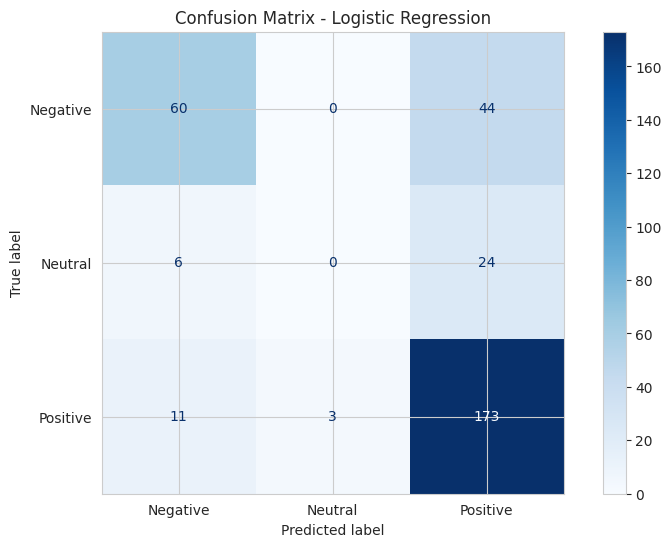

In [79]:
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_model.classes_
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### 📊 Interpretation: Logistic Regression

*Analyze the results:*


1. **Overall performance:**
   
   The Logistic Regression model obtained an accuracy of **72.59%**. It performed well overall and classified correctly most of the positive and negative reviews.

2. **Strengths:**
   - High accuracy of 72.59%.
   - Great at identifying positive reviews (F1-score = 0.81).
   - Fast time to train and efficient performance on TF-IDF features.

3. **Weaknesses:**
   - The model didn't classify correctly any neutral reviews (F1-score = 0.00).
   - It has tendency to predict positive sentiment more frequently than neutral sentiment.
   - Performance was lower for those of minority classes compared to the positive class.

4. **Confusion matrix insights:**
   
   The confusion matrix displays that the model correctly classified **173 positive** and **60 negative** reviews. However, not one of the **30 neutral** reviews were correctly predicted. Most neutral reviews were incorrectly classified as positive, indicating that the model struggled with recognizing neutral sentiment from positive sentiment.

## Evaluate Model 2: Naive Bayes

In [80]:
print("=" * 50)
print("NAIVE BAYES RESULTS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb, average='weighted')
recall = recall_score(y_test, y_pred_nb, average='weighted')
f1 = f1_score(y_test, y_pred_nb, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

NAIVE BAYES RESULTS
Accuracy:  0.7508
Precision: 0.7002
Recall:    0.7508
F1-Score:  0.7042

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.57      0.69       104
     Neutral       0.00      0.00      0.00        30
    Positive       0.72      0.97      0.83       187

    accuracy                           0.75       321
   macro avg       0.53      0.51      0.50       321
weighted avg       0.70      0.75      0.70       321



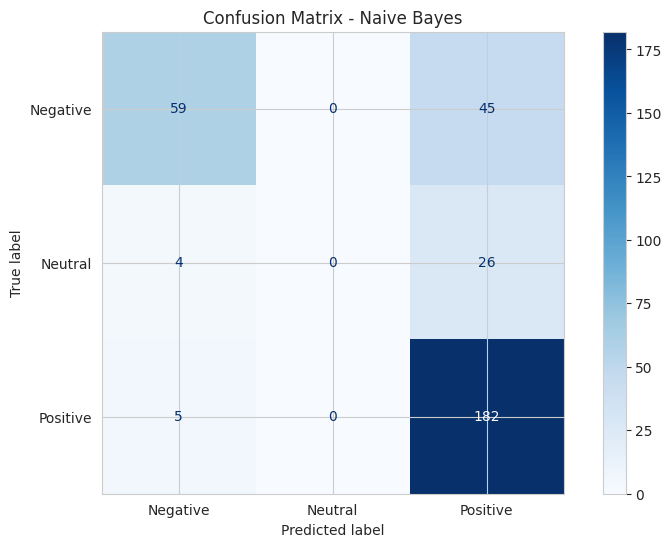

In [81]:
cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_model.classes_
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

### 📊 Interpretation: Naive Bayes

*Analyze the results:*

### 📊 Interpretation: Naive Bayes

1. **Overall performance:**
   
   The Naive Bayes model performed well overall, it correctly classified most positive and a good share of negative reviews. It achieved overall good accuracy but struggled to classify neutral reviews.

2. **Strengths:**
   - Correctly identified most positive reviews.
   - Simple, fast, and works well with TF-IDF text features.
   - Delivered results comparable to Logistic Regression.

3. **Weaknesses:**
   - Failed in correctly classifying any neutral reviews.
   - Misclassified many negative and neutral reviews as positive.
   - Performance dropped on the minority classes because of class imbalance.

4. **Confusion matrix insights:**
   
   The confusion matrix shows that the model correctly classified **182 positive** and **59 negative** reviews. However, **zero neutral reviews** were correctly predicted. Most neutral reviews were classified as positive, showing that the model had difficulty distinguishing neutral from positive sentiment.

## Evaluate Model 3 (Optional)

In [82]:
# Calculate metrics for your third model (if applicable)
# YOUR CODE HERE

In [83]:
# Plot confusion matrix for your third model (if applicable)
# YOUR CODE HERE

## Model Comparison

In [84]:
# Calculate Logistic Regression metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted')
rec_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

# Calculate Naive Bayes metrics
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted')
rec_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

# Create comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [acc_lr, acc_nb],
    'Precision': [prec_lr, prec_nb],
    'Recall': [rec_lr, rec_nb],
    'F1-Score': [f1_lr, f1_nb]
})

display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.725857,0.670640,0.725857,0.685742
1,Naive Bayes,0.750779,0.700178,0.750779,0.704202


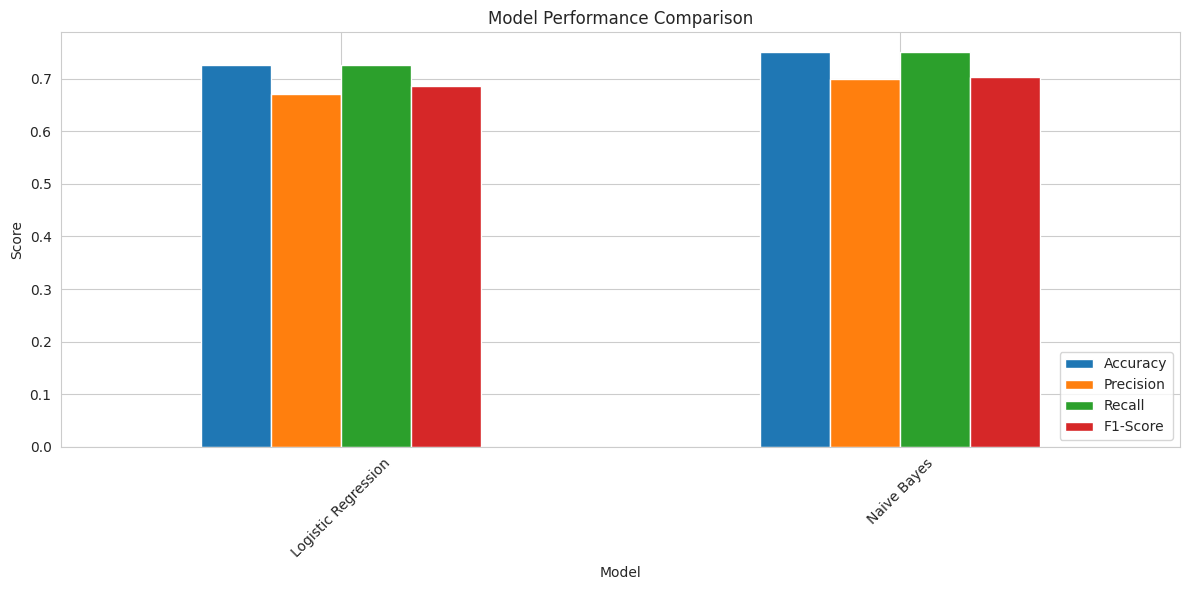

In [85]:
results.set_index('Model').plot(kind='bar', figsize=(12, 6))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 📊 Model Comparison Analysis

*Compare and contrast your models:*

1. **Which model performed best?**:
2. **What metrics did you prioritize and why?**:
3. **Trade-offs between models**:
4. **Which model would you recommend for deployment?**:

## Error Analysis (Optional but Recommended)

In [86]:
# Analyze misclassified examples
# YOUR CODE HERE

# Hint: Find examples where the model was wrong
# misclassified_indices = np.where(y_pred_lr != y_test)[0]
# print(f"Number of misclassified examples: {len(misclassified_indices)}")

# Display some misclassified examples
# for idx in misclassified_indices[:5]:
#     print(f"\nText: {X_test.iloc[idx]}")
#     print(f"True label: {y_test.iloc[idx]}")
#     print(f"Predicted label: {y_pred_lr[idx]}")
#     print("-" * 80)

### 📊 Error Analysis Insights

*What patterns do you notice in the errors?*

1. **Which model performed best?**

  Logistic Regression performed slightly better overall, achieving a marginally higher accuracy and a better balance between precision, recall, and F1-score. Although Naive Bayes correctly classified more positive reviews, Logistic Regression delivered a more balanced performance across the full dataset.

2. **What metrics did you prioritize and why?**

  I prioritized **accuracy** and **F1-score** since together they provide a solid overall picture of model performance. Accuracy shows how often the model made correct predictions, while the F1-score balances precision and recall, making it valuable when the dataset contains class imbalance.

3. **Trade-offs between models:**
   
  Logistic Regression produced more balanced predictions and slightly stronger overall performance. Naive Bayes was faster and classified more positive reviews correctly, but it also misclassified more negative and neutral reviews as positive. Neither model was able to accurately predict the neutral class well, largely due to there being relatively few neutral examples in the dataset.

4. **Which model would you recommend for deployment?**
  
 I would recommend **Logistic Regression** for deployment since it delivered the strongest overall performance and more balanced predictions. It's more reliable for general sentiment classification on this dataset while maintaining solid accuracy and F1-score.

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

*Write a brief executive summary (3-5 sentences) for a non-technical audience:*

This project developed and analyzed two machine learning models to automatically classify Amazon headphone reviews as positive, neutral, or negative. Both models performed well overall, but Logistic Regression achieved the most balanced and accurate results. The models were highly effective at identifying positive reviews but had difficulty recognizing neutral reviews due to fewer samples in the dataset. Overall, Logistic Regression is the recommended model for helping businesses quickly analyze customer feedback and gain a clearer understanding of customer satisfaction.


## 🎯 Key Findings

*List your main discoveries:*


1. **Dataset insights**:
   - The dataset included customer reviews labeled as positive, neutral, and negative based on star ratings.
   - Positive reviews made up the major portion of the dataset, while neutral reviews were more less common.
   - The imbalance made it more difficult for the models to correctly identify neutral sentiment.

2. **Model performance**:
   - Both Logistic Regression and Naive Bayes performed well overall, each obtaining around 70% accuracy.
   - Logistic Regression provided more balanced predictions across all three classes.
   - Both models successfully identified correctly most positive reviews but struggled with neutral reviews.

3. **Best model and why**:
   - Logistic Regression is the best performing model because it achieved the highest overall accuracy along with a better balance between precision, recall, and F1-score.
   - It's more reliable predictions and would be the preferred model choice for real-world sentiment analysis.

4. **Surprising discoveries**:
   - Both models failed to correctly classify neutral reviews, despite performing well on positive and negative reviews.
   - This highlights how class imbalance can significantly affect machine learning performance and suggests that gathering more neutral examples could improve future results.

## 💼 Business Recommendations

*How can these results be used in practice?*

### 1. Immediate applications:
- Businesses can use this model to analyze customer reviews automatically and quickly to determine whether feedback is positive, neutral, or negative.
- Customer service teams can prioritize negative reviews in order to resolve issues faster.
- Marketing teams can track customer satisfaction and identify common product strengths and weaknesses.

### 2. Who should use this model?
- E-commerce companies (i.e. Amazon, online retailers, etc.)
- Product managers who want better insight on customer opinions.
- Customer support teams that need to respond promptly to negative feedback.
- Businesses handling large quantities of online reviews.

### 3. How to interpret predictions:
- A positive prediction suggests customers are generally satisfied with product.
- A negative prediction indicates customer dissatisfaction and can warrant further investigation.
- Predictions should be used as a decision-support tool instead of a final word and reviewed alongside the original customer comments, especially for uncertain or neutral cases.

### 4. Warning signs to watch for:
- The model may misclassify neutral reviews because there were relatively few neutral examples in the training data.
- Predictions should not be treated as totally accurate and should be monitored over time.
- The model should be retrained periodically as new customer reviews become available to maintain performance.


## ⚠️ Limitations

*Be honest about the limitations of your analysis:*

### 1. Data limitations:
- The dataset had fewer neutral reviews than positive and negative reviews, creating class imbalance.
- Customer reviews may contain spelling errors, slang, or sarcasm, all of which are difficult for the models to understand.
- The analysis was based on one product category, so results may not represent all types of customer reviews.

### 2. Model limitations:
- Both Logistic Regression and Naive Bayes struggled to correctly recognize neutral reviews.
- The models rely solely on the text in the reviews and don't consider additional information such as product features or customer history.
- Neither model fully captures context or complex language adequately.

### 3. Generalization concerns:
- Results may vary when applied to reviews from other products, industries, or websites.
- Additional training data would likely aid in improving performance on new datasets.
- The models should be validated before being deployed in a different business setting.

### 4. Resource constraints:
- Larger, more balanced datasets would likely improve model performance.
- Regular retraining is needed as customer language and product trends evolve over time.
- Greater computing resources and more advanced models could further improve prediction accuracy.

## 🚀 Future Improvements

*What would you do with more time/resources?*

1### 1. Data collection:
- Gather a larger dataset with more customer reviews, especially neutral reviews, to reduce class imbalance.
- Include reviews from different products and websites to improve the model's ability to generalize.
- Collect more recent reviews so the model reflects current customer opinions and language.

### 2. Feature engineering:
- Experiment with additional text preprocessing techniques such as stemming or lemmatization.
- incorporate addiional features like review length and product category to provide more context to the model.
- Utilize word embeddings or contextual text representations to better capture the meaning of reviews.

### 3. Advanced models:
- Compare Logistic Regression and Naive Bayes against more models that are advanced, such as Support Vector Machines (SVM), Random Forest, XGBoost, or deep learning models like LSTM and BERT.
- Perform hyperparameter tuning to increase model performance.
- Use cross-validation to gain more reliable evaluation results.

### 4. Deployment considerations:
- Deploy the model as part of a web application or customer feedback dashboard to support real-time sentiment analysis.
- Continuously monitor model performance and retrain it with new customer reviews to maintain accuracy.
- Create a process for handling uncertain predictions and regularly evaluate the model to ensure consistent and adequate performance over time.

## 🎓 Lessons Learned

*Reflect on your experience:*

## 🎓 Lessons Learned

### 1. Technical skills gained:
- I gained the technical skills of preprocessing  text data, converting text into numerical features using TF-IDF, and training machine learning models for sentiment analysis.
- I also gained experience evaluating models using accuracy, precision, recall, F1-score, and confusion matrices.

### 2. Challenges overcome:
- One of the biggest challenges was preparing the text data and understanding how each preprocessing step would influence the models.
- I also learned how to compare multiple models and interpret their evaluation metrics to determine which one had the best performance.

### 3. What would you do differently?
- If I were to do this project again, I would aim to collect a larger and more balanced dataset, especially with more neutral reviews.
- I'd also experiment with additional machine learning algorithms and tune their parameters to see if performance could be improved.

### 4. Most valuable insight:
- The most valuable insight I gained was realizing that choosing the right model involves more than just looking at accuracy. Evaluating precision, recall, F1-score, and the confusion matrix provided a clearer image of each of the model's strengths and weaknesses.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*